### Modeling - Predicting Breast Tumor Diagnosis with Machine Learning

**Breast Cancer Wisconsin Diagnostic Dataset**<br>
Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B.

#### Variables
1) ID number
2) Diagnosis (M = malignant, B = benign)

3-32)
Ten real-valued features are computed for each cell nucleus:

	a) radius (mean of distances from center to points on the perimeter)
	b) texture (standard deviation of gray-scale values)
	c) perimeter
	d) area
	e) smoothness (local variation in radius lengths)
	f) compactness (perimeter^2 / area - 1.0)
	g) concavity (severity of concave portions of the contour)
	h) concave points (number of concave portions of the contour)
	i) symmetry 
	j) fractal dimension ("coastline approximation" - 1)

Go to [Kaggle](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data/data) for variable definitions

In [33]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,precision_recall_curve
)

import matplotlib.pyplot as plt

### Data Preprocessing

In [34]:
# Load the dataset
df = pd.read_csv('raw_tumor_feature_data.csv')
df.head(3)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [35]:
# Subset df to the optional measurements we determined in 03_feature_engineering.ipynb
col_to_keep = ['diagnosis','area_worst', 'compactness_mean', 'concavity_mean', 'fractal_dimension_mean',\
                'smoothness_worst', 'symmetry_mean', 'texture_mean']

df_subset = df[col_to_keep]

# Split into X and y
y = df_subset['diagnosis']
X = df_subset.drop('diagnosis',axis=1)

# Modify y so M=1 and B=0
y = y.replace({'M':1,'B':0})

/var/folders/cq/gp4mmh_532d1t3573lxjzj5w0000gp/T/ipykernel_63290/71403923.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'M':1,'B':0})


### Hyperparameter Tuning & Model Evaluation

In [36]:
df_subset.diagnosis.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

The target variable is imbalanced, so we're going to stratify y and use StratifiedKFold. 

In [37]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Instantiate a random forest classifier
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# K-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with cross-validation
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print("Best Parameters:\n", grid_search.best_params_)

# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluate performance
print("\nModel Evaluation Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
 {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Model Evaluation Metrics:
Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
F1 Score:  0.9512
ROC AUC:   0.9957

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



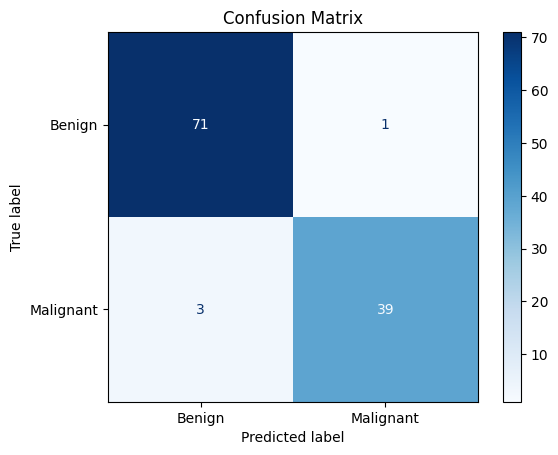

In [38]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

These are really good results, but I'd like recall to be higher since I'm classifying tumors as malignant or not. This model fails to catch 3 malignant tumors. 

### Methods to maximize recall
#### 1. Emphasize Recall in GridSearchCV, assign class_weight = 'balanced'

In [39]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Instantiate a random forest classifier
rf = RandomForestClassifier(random_state=42,class_weight='balanced')

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# K-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with cross-validation, emphasizing recall
grid_search = GridSearchCV(rf, param_grid, cv=cv, scoring='recall', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print("Best Parameters:\n", grid_search.best_params_)

# Predict on test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

# Evaluate performance
print("\nModel Evaluation Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
 {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Model Evaluation Metrics:
Accuracy:  0.9737
Precision: 1.0000
Recall:    0.9286
F1 Score:  0.9630
ROC AUC:   0.9980

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



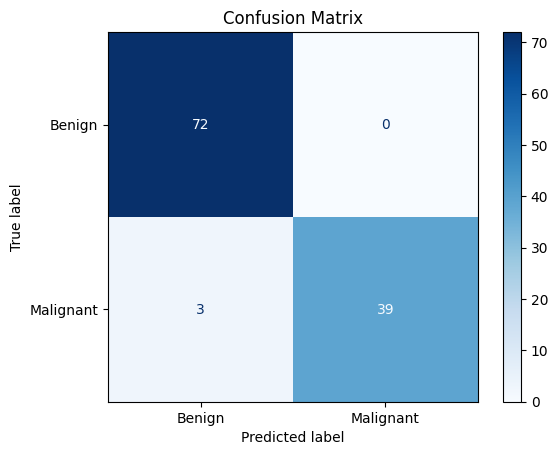

In [40]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

I first tried emphasizing recall in GridSearchCV and setting class_weight to 'balanced' as separate steps. On their own, they didn't do much. Together, they don't fix the false negative problem, though they do eliminate false positives. In this case, false negatives are worse that false positives, so I'm going to keep trying to minimize them, even if that slightly increases false positives. 

#### 2.Manually tune the threshold

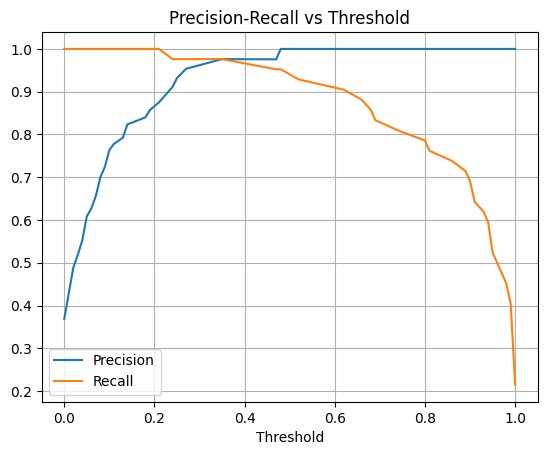

In [41]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Plot precision-recall tradeoff
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision-Recall vs Threshold")
plt.grid()
plt.show()


It looks like a threshold of about 0.3 could boost recall without sacrificing too much precision. Let's see how it looks below. 

In [42]:
# Get predicted probabilities
y_proba = best_model.predict_proba(X_test)[:, 1]

# Try a few thresholds based on the plot above
threshold = 0.3
y_pred_thresh = (y_proba >= threshold).astype(int)

# Evaluate again
print(classification_report(y_test, y_pred_thresh))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



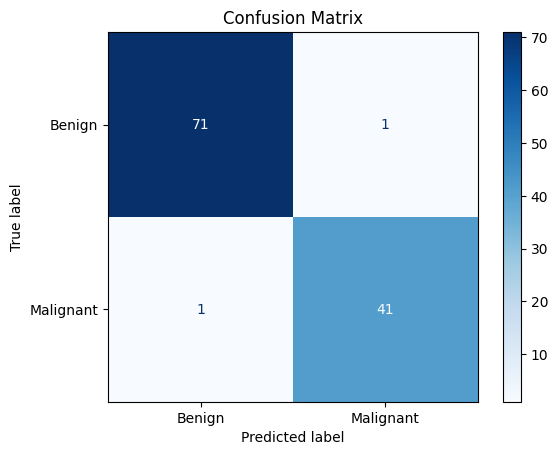

In [43]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_thresh)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [44]:
# Calculate % of false negatives
1/(71+1+1+41)

0.008771929824561403

**Threshold = 0.2:** No false negatives, 6 false positives <br>
**Threshold = 0.3:** 1 false negative, 1 false positive

Based on this, I'm going to set threshold = 0.3. While we really want to minimize false negatives, false positives can also be cause harm to a patient, leading to unnecessary stress, invasive procedures, and financial burden. With this model, false negatives and false positives each make up <1% of cases, which is excellent.  


During the tuning process, I also tried adjusting the threshold without class_weight = 'balanced' and GridSearchCV emphasizing recall. The results were a higher false negative rate and a similar false positive rate as we see now. So I'll keep those hyperparameters in the final model. 
### Final Model 
- 80/20 train/test split with a stratified y
- X contains `area_worst`, `compactness_mean`, `concavity_mean`, `fractal_dimension_mean`, `smoothness_worst`, `symmetry_mean`, and `texture_mean`
- RandomForestClassifer with 'class_weight':'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100
- Threshold = 0.3

Let's double check we get the same result when we put it all together.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

final_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

final_rf.fit(X_train, y_train)

# Predict probabilities on test set
y_proba = final_rf.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_proba >= 0.3).astype(int)

# Evaluate
print("\nModel Evaluation Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_thresh):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_thresh):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_thresh):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_thresh):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_thresh))



Model Evaluation Metrics:
Accuracy:  0.9825
Precision: 0.9762
Recall:    0.9762
F1 Score:  0.9762
ROC AUC:   0.9980

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99        72
           1       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



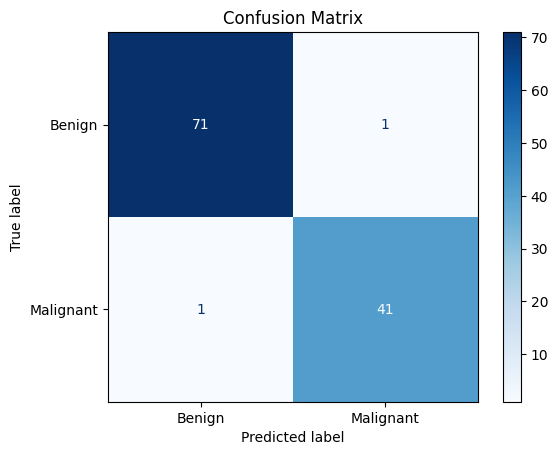

In [46]:
cm = confusion_matrix(y_test, y_pred_thresh)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

Success! :)